In [1]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [2]:
# Necessary imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit_machine_learning.utils import algorithm_globals

# Set seed for random generators
algorithm_globals.random_seed = 38798451

from QNN_framework import Reuploading_classifier
from data_loading import Build_artitifical_data_set,load_csv_data,load_cancer_data

from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B, AQGD, ADAM

In [3]:
# read data using pandas
X,y = load_cancer_data("../data/breast+cancer+wisconsin+diagnostic/wdbc.data")

In [4]:
n_feature = X.shape[1]
n_class = len(np.unique(y))

In [14]:
args_embeding= {"name": "brickwall", "circular": True, "reps": 1}
args_anzats= {"name": "brickwall", "circular": True, "reps": 2}
reps = 2
qnn_args = dict(
    reps=reps,
    args_embeding=args_embeding,
    args_anzats=args_anzats,
    pre_anzats=True
)

estimator_classifier = Reuploading_classifier(
    n_feature=n_feature,
    n_class=n_class,
    qnn_args=qnn_args,
    optimizer=COBYLA(maxiter=100,rhobeg=0.4)
    #optimizer=L_BFGS_B(maxiter=50)
)


In [ ]:
# fit classifier to data
estimator_classifier.fit(X, y)
# score classifier
score = estimator_classifier.score(X, y)
print(f"Classifier score: {score}")

/home/tardant/Bureau/Qiskit/.venv/lib/python3.12/site-packages/scipy/_lib/pyprima/common/preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 194
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


Classifier score: 0.6010544815465729


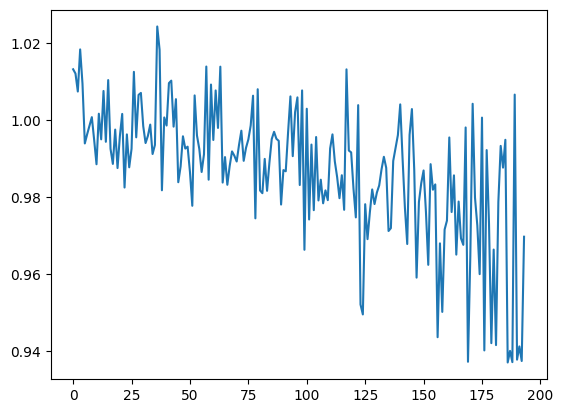

In [12]:
obj_func_gradient = estimator_classifier.objective_func_vals
plt.plot(obj_func_gradient)